In [15]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier

data = pd.read_csv('NO3excel.csv')

data['temp_bin'] = (data['temprature'] >= 26).astype(int)
data['humid_bin'] = (data['humid'] >= 50).astype(int)
data['is_holiday'] = data['day'].isin(['土', '日']).astype(int)
data['target'] = (data['price'] > 0).astype(int)

X = data[['temp_bin', 'humid_bin', 'is_holiday']]
Y = data['target']

clf = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=0)
clf = clf.fit(X, Y)

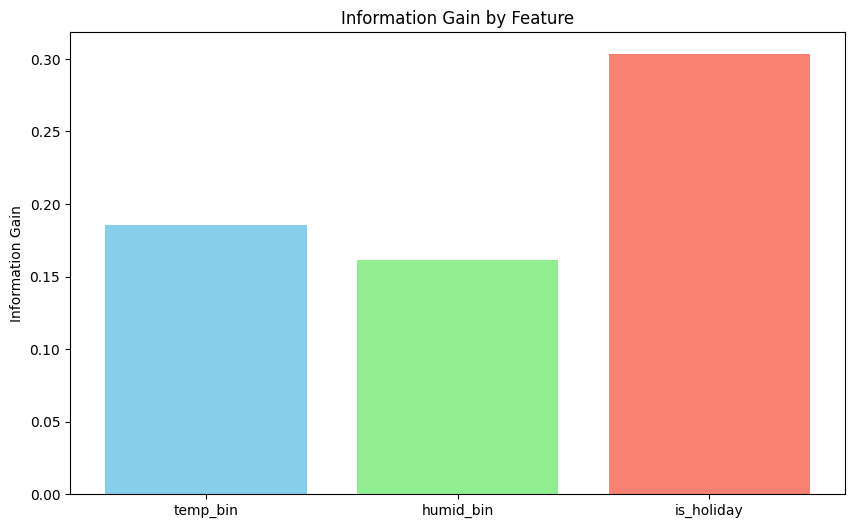

In [16]:
def calculate_entropy(y):
    prob = y.value_counts(normalize=True)
    return -np.sum(prob * np.log2(prob + 1e-15))

# 情報利得（エントロピーがどれだけ減ったか）を計算する関数を定義します。
def calculate_information_gain(df, feature, target):
    total_entropy = calculate_entropy(df[target])
    values = df[feature].unique()
    weighted_entropy = 0
    for v in values:
        subset = df[df[feature] == v]
        weight = len(subset) / len(df)
        weighted_entropy += weight * calculate_entropy(subset[target])
    return total_entropy - weighted_entropy

# 各条件（温度、湿度、休日）の情報利得を計算します。
features = ['temp_bin', 'humid_bin', 'is_holiday']
gains = {f: calculate_information_gain(data, f, 'target') for f in features}

# 計算結果を棒グラフとして描画します。
plt.figure(figsize=(10, 6))
plt.bar(gains.keys(), gains.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Information Gain')
plt.title('Information Gain by Feature')
plt.savefig('information_gain.png')

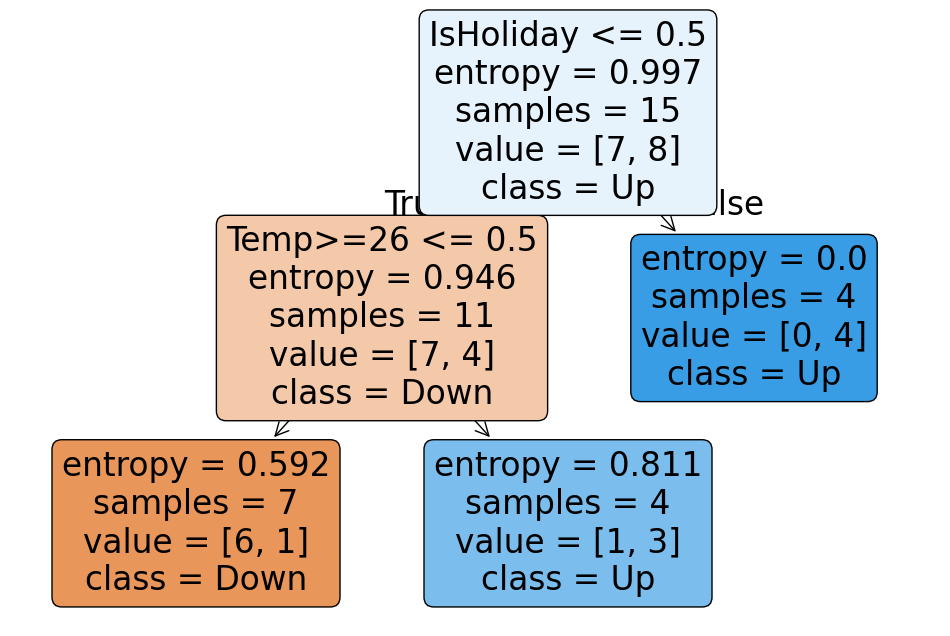

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))

plot_tree(clf,
          feature_names=['Temp>=26', 'Humid>=50', 'IsHoliday'],
          class_names=['Down', 'Up'],
          filled=True,
          rounded=True)

plt.savefig('decision_tree.png')